githubのコードを参考に書き直す。cut_off_degreeが親セットのサイズに相当する。degreeがK次のモーメントの指定に相当。funはmaxかminが指定可能で、T1＆T2の指定に相当する。
pruningCutは係数の評価をしないから不要、Bは事前知識的なものと思うがこれも不要。

In [1]:
import pandas as pd

import itertools
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from sklearn.utils import check_array, check_scalar

from lingam import DirectLiNGAM

np.random.seed(0)

class HighDLingam(DirectLiNGAM):
    
    def __init__(self, max_in_degree=3, degree=4, fun=max, pruning_cut=None, cut_off_scaling=0.5, **kwargs):
        super().__init__(**kwargs)

        self._max_in_degree = check_scalar(max_in_degree, "max_in_degree", int, min_val=2, include_boundaries="neither")
        self._degree = check_scalar(degree, "degree", int, min_val=1)
    
        if fun != max and fun != min:
            raise RuntimeError("only max or min")
            
        self._fun = fun
    
        if pruning_cut is None:
            self._pruning_cut = pruning_cut
        else:
            self._pruning_cut = check_scalar(pruning_cut, "pruning_cut", (int, float), min_val=0)
        
        self._cut_off_scaling = check_scalar(cut_off_scaling, "cut_off_scaling", (int, float), min_val=0)
    
    def _calc_tau(self, k, pa, ch):
        return abs(np.mean(pa ** (k - 1) * ch) * np.mean(pa ** 2) - np.mean(pa ** k) * np.mean(pa * ch))

    def _get_tau_single(self, i, j, degree, condition_set, max_in_degree):
        j = list(set(j) - set([i]))
        p = self._Y.shape[1]
        prune_stat = np.array([1e5 for _ in range(p)])
        tau_stat = 1e5
        
        if len(condition_set) == 0:
            prune_stat[j] = list(map(lambda j_: self._calc_tau(degree, self._Y[:, i], self._Y[:, j_]), j))
            tau_stat = self._fun(prune_stat[j])
            return prune_stat, tau_stat
        
        size_of_set = min(max_in_degree, len(condition_set))
        
        # たぶんDvzに当たる
        if len(condition_set) == 1:
            condition_sub_set = [tuple(condition_set)]
        else:
            # XXX: たぶんこのあたりが変？
            if True:
                condition_sub_set = list(itertools.combinations(condition_set, size_of_set))
            else:
                # XXX: 和集合になっていない。|C| <= J になっていない。
                condition_sub_set = []
                for s in range(1, size_of_set + 1):
                    condition_sub_set = [*condition_sub_set, *list(itertools.combinations(condition_set, s))]
        
        print("============== get_tau_single ==============")
        print("condition_set:", condition_set)
        print("candidates:", condition_sub_set)
        
        for z in range(len(condition_sub_set)):
            print("XXX: ", set(condition_set))
            print("YYY: ", set(condition_sub_set[z]))
            condition_nodes_to_test = list(set(condition_set) - set(condition_sub_set[z]))
            
            print(f"{z}th candidate", condition_nodes_to_test)
            
            if len(condition_nodes_to_test) == 0:
                continue
                
            X = self._Y[:, condition_sub_set[z]].reshape(len(self._Y), -1)
            y = self._Y[:, i].reshape(len(self._Y), -1)
            res = y - LinearRegression().fit(X, y).predict(X)
            
            tau_C = list(map(lambda j_: self._calc_tau(k=degree, pa=res, ch=self._Y[:, j_]), j))
            
            tau_stat = min(tau_stat, self._fun(tau_C))
            
            prune_stat[condition_nodes_to_test] = np.min([
                prune_stat[condition_nodes_to_test],
                list(map(lambda j: self._calc_tau(k=degree, pa=res, ch=self._Y[:, j]), condition_nodes_to_test))
            ], axis=0)
            
        return prune_stat, tau_stat
        
    def fit(self, Y):
        self._Y = check_array(Y)
        
        if self._pruning_cut is None:
            cut_off = 0
        else:
            cut_off = pruning_cut
        
        ordered = []
        p = self._Y.shape[1]
        
        unordered = list(range(p))
        
        prune_stats = (1 - np.eye(p)) * 1e5
        
        while len(unordered) > 1:
            print(f"============================= step={len(ordered)} =================================")
            
            output_prune_stats = []
            output_tau_stats = []
            for i in unordered:
                cond_set = set.intersection(set(ordered), set(np.argwhere(prune_stats[i] > cut_off).flatten()))
                cond_set = set.union(cond_set, set(ordered[-1:] if len(ordered) > 0 else set()))
            
                print(f"unordered = {i}", cond_set)
                prune_stat, tau_stat = self._get_tau_single(i, unordered, self._degree, cond_set, self._max_in_degree)
                
                output_prune_stats.append(prune_stat)
                output_tau_stats.append(tau_stat)
            output_prune_stats = np.array(output_prune_stats)
            output_tau_stats = np.array(output_tau_stats)
            
            # XXX:
            display("--------------------")
            display(pd.DataFrame(output_prune_stats))
            display(pd.DataFrame(output_tau_stats))
            
            root = unordered[np.argmin(output_tau_stats)]
            pa = [o for o, ps in zip(ordered, prune_stats[root]) if ps > cut_off]
            pa = set.intersection(set(ordered), set(np.argwhere(prune_stats[root, :] > cut_off).flatten()))
            pa = set.union(pa, set(ordered[-1:] if len(ordered) > 0 else set()))
            
            if len(ordered) > 0:
                #print(unordered, ordered)
                #print(prune_stats)
                #print("#", prune_stats[np.ix_(unordered, ordered)].reshape(-1, len(ordered)))
                #print("@", output_prune_stats[:, ordered].reshape(-1, len(ordered)))
                prune_stats[np.ix_(unordered, ordered)] = np.min(
                    [prune_stats[np.ix_(unordered, ordered)].reshape(-1, len(ordered)),
                     output_prune_stats[:, ordered].reshape(-1, len(ordered))], axis=(0, 1))
            
            if self._pruning_cut is None:
                cut_off = max(cut_off, min(output_tau_stats) * self._cut_off_scaling)
            
            if True:
                print("==== step=", len(ordered), "====")
                print("Roots:\n", root)
                print("Parents:\n", pa)
                #print("Roots:\n", root + 1)
                #print("Parents:\n", np.array(list(pa)) + 1)
            
            ordered.append(root)
            unordered.remove(root)
            
        return {"top_order": [*ordered, *unordered], "prune": prune_stats}

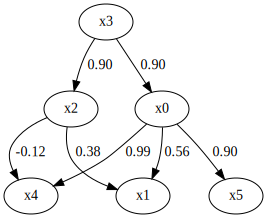

============================= step=0 =================================
unordered = 0 set()
unordered = 1 set()
unordered = 2 set()
unordered = 3 set()
unordered = 4 set()
unordered = 5 set()


'--------------------'

,0,1,2,3,4,5
0,100000.000000,0.035746,0.115065,0.125497,0.019415,0.006829
1,0.068227,100000.000000,0.108749,0.163702,0.048287,0.054632
2,0.104658,0.064168,100000.000000,0.122818,0.104164,0.091950
3,0.004031,0.006102,0.002596,100000.000000,0.003427,0.003955
4,0.070848,0.081211,0.143807,0.138593,100000.000000,0.061527
5,0.073275,0.078625,0.130245,0.159933,0.054929,100000.000000


,0
0,0.125497
1,0.163702
2,0.122818
3,0.006102
4,0.143807
5,0.159933


==== step= 0 ====
Roots:
 3
Parents:
 set()
============================= step=1 =================================
unordered = 0 {3}
============== get_tau_single ==============
condition_set: {3}
candidates: [(3,)]
XXX:  {3}
YYY:  {3}
0th candidate []
unordered = 1 {3}
============== get_tau_single ==============
condition_set: {3}
candidates: [(3,)]
XXX:  {3}
YYY:  {3}
0th candidate []
unordered = 2 {3}
============== get_tau_single ==============
condition_set: {3}
candidates: [(3,)]
XXX:  {3}
YYY:  {3}
0th candidate []
unordered = 4 {3}
============== get_tau_single ==============
condition_set: {3}
candidates: [(3,)]
XXX:  {3}
YYY:  {3}
0th candidate []
unordered = 5 {3}
============== get_tau_single ==============
condition_set: {3}
candidates: [(3,)]
XXX:  {3}
YYY:  {3}
0th candidate []


...

==== step= 3 ====
Roots:
 2
Parents:
 {0, 1, 3}
============================= step=4 =================================
unordered = 4 {0, 1, 2, 3}
============== get_tau_single ==============
condition_set: {0, 1, 2, 3}
candidates: [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
XXX:  {0, 1, 2, 3}
YYY:  {0, 1, 2}
0th candidate [3]
XXX:  {0, 1, 2, 3}
YYY:  {0, 1, 3}
1th candidate [2]
XXX:  {0, 1, 2, 3}
YYY:  {0, 2, 3}
2th candidate [1]
XXX:  {0, 1, 2, 3}
YYY:  {1, 2, 3}
3th candidate [0]
unordered = 5 {0, 1, 2, 3}
============== get_tau_single ==============
condition_set: {0, 1, 2, 3}
candidates: [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
XXX:  {0, 1, 2, 3}
YYY:  {0, 1, 2}
0th candidate [3]
XXX:  {0, 1, 2, 3}
YYY:  {0, 1, 3}
1th candidate [2]
XXX:  {0, 1, 2, 3}
YYY:  {0, 2, 3}
2th candidate [1]
XXX:  {0, 1, 2, 3}
YYY:  {1, 2, 3}
3th candidate [0]


'--------------------'

,0,1,2,3,4,5
0,7.210339e-06,3.962299e-06,1.531038e-06,1.588893e-06,100000.0,100000.0
1,4.529277e-07,9.333099e-07,2.997890e-07,3.961795e-07,100000.0,100000.0


,0
0,3.014134e-06
1,4.356219e-07


==== step= 4 ====
Roots:
 5
Parents:
 {0, 1, 2, 3}
[3 0 1 2 5 4]
[4 1 2 3 6 5]


In [2]:
import lingam

np.random.seed(0)

m = np.array([
    [ 0.000,  0.000,  0.000,  0.895,  0.000,  0.000],
    [ 0.565,  0.000,  0.377,  0.000,  0.000,  0.000],
    [ 0.000,  0.000,  0.000,  0.895,  0.000,  0.000],
    [ 0.000,  0.000,  0.000,  0.000,  0.000,  0.000],
    [ 0.991,  0.000, -0.124,  0.000,  0.000,  0.000],
    [ 0.895,  0.000,  0.000,  0.000,  0.000,  0.000]
])

if False:
    m = np.zeros((6, 6))
    for i in range(6 - 1):
        m[i +1, i]  = 1

sample_size = 10000

error_vars = [0.2, 0.2, 0.2, 1.0, 0.2, 0.2]
params = [0.5 * np.sqrt(12 * v) for v in error_vars]

generate_error = lambda p: np.random.uniform(-p, p, size=sample_size)
e = np.array([generate_error(p) for p in params])

X = np.linalg.pinv(np.eye(len(m)) - m) @ e
X = X.T

display(lingam.utils.make_dot(m))

model = HighDLingam()
ret = model.fit(X)

print(np.array(ret["top_order"]))
print(np.array(ret["top_order"]) + 1)